<center>
    <h1>Monopropellant Thruster Performance Prediction</h1>
    <h2>Final Project Report</h2>
    SADOVENKO Dimitri<br>
    ROBERT Célestin<br>
    RASSED Antoine<br>
    MMN5
</center>

---

### 1. Context and Objective
**Context:** Qualifying spacecraft thrusters involves costly ground "Hot Fire Tests". However, these tests cannot perfectly replicate space conditions, and real-time performance monitoring in orbit is limited.

**Objective:** The goal is to build a **"Virtual Sensor"** (Performance Modelling). We aim to predict **Average Thrust** and **Mass Flow Rate** based on command sequences and aging status. This allows engineers to estimate fuel consumption and thrust accuracy without relying solely on sparse physical telemetry.

### 2. Methodology
To capture the complex thermal dynamics of the thrusters, we evolved from simple global statistics to an **Advanced Windowing Strategy**:
* **Data Processing:** Each firing test is sliced into **10-second windows** (1000 rows). This granularity captures transient behaviors (warm-up, tail-off) while smoothing high-frequency sensor noise.
* **Physics-Informed Features:** We enriched the dataset with domain knowledge features such as **Inertia** (simulating thermal lag), **Startup Ramps** (ignition phase), and **Theoretical Thrust** (PIML) to guide the learning process.
* **Modeling Strategy:** We utilize a **Bagging Ensemble of Multi-Layer Perceptrons (MLP)**. This Deep Learning approach proved superior to Decision Trees for approximating continuous physical functions and ensuring robustness.

### 3. Train / Test Split Strategy
We strictly follow the industrial guidelines provided in the dataset description to ensure realistic validation:
* **TRAIN Set (SN01 - SN12):** Ground Qualification Units used for training the model.
* **TEST Set (SN13 - SN24):** Flight Units (never seen during training). These act as the final blind test to evaluate the model's generalization capability on new hardware.

## 1.Imports

In [31]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor


from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

METADATA_FILE = 'metadata.csv'
TRAIN_FOLDER = 'dataset/train' 
TEST_FOLDER = 'dataset/test'

In [3]:
def process_folder_full(folder_path, df_meta):
    """
    Scans a folder, reads each CSV file, and aggregates it into a single row.
    Filter: Keeps only the data points where the engine is active (ton > 0).
    """
    dataset = []
    
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return pd.DataFrame()
        
    files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    print(f"Processing '{folder_path}': {len(files)} files found...")
    
    for i, filename in enumerate(files):
        # Link with metadata
        meta_row = df_meta[df_meta['filename'] == filename]
        
        if not meta_row.empty:
            row = meta_row.iloc[0]
            filepath = os.path.join(folder_path, filename)

            try:
                df_tir = pd.read_csv(filepath)
                
                # --- ACTIVE FILTER ---
                # We only keep data when the valve is open
                df_active = df_tir[df_tir['ton'] > 0]
                
                if len(df_active) > 0:
                    data_row = {
                        # --- IDENTIFIERS (Crucial for visualization!) ---
                        'sn': row['sn'],
                        'test_id': row['test_id'],

                        # Inputs (X)
                        'pressure': row['test_pressure'],
                        'duration': len(df_active) * 0.01, # 1 row = 0.01s (100Hz)
                        'cumulated_throughput': row['cumulated_throughput'],
                        'cumulated_pulses': row['cumulated_pulses'],
                        
                        # Targets (Y) - Averages
                        'avg_thrust': df_active['thrust'].mean(),
                        'avg_mfr': df_active['mfr'].mean()
                    }
                    dataset.append(data_row)
            except Exception:
                pass # Ignore corrupted files
        
        if i % 500 == 0 and i > 0:
            print(f"... {i} files processed")
            
    return pd.DataFrame(dataset)

In [4]:
if os.path.exists(METADATA_FILE):
    df_meta = pd.read_csv(METADATA_FILE)
    # [cite_start]Filter out anomalies to learn nominal performance [cite: 90]
    df_meta = df_meta[df_meta['anomalous'] == False]
    
    print("--- 1. GENERATING TRAIN SET (SN01-SN12) ---")
    df_train = process_folder_full(TRAIN_FOLDER, df_meta)
    
    print("\n--- 2. GENERATING TEST SET (SN13-SN24) ---")
    df_test = process_folder_full(TEST_FOLDER, df_meta)
    
    print(f"\nDATA READY: Train={len(df_train)} rows | Test={len(df_test)} rows")
else:
    raise FileNotFoundError("Metadata file not found.")

--- 1. GENERATING TRAIN SET (SN01-SN12) ---
Processing 'dataset/train': 1267 files found...
... 500 files processed
... 1000 files processed

--- 2. GENERATING TEST SET (SN13-SN24) ---
Processing 'dataset/test': 1344 files found...
... 500 files processed
... 1000 files processed

DATA READY: Train=1136 rows | Test=1206 rows


## 2.Data Analysis

In [8]:
# Define features

feature_names = ['pressure', 'duration', 'cumulated_throughput', 'cumulated_pulses']

feature_columns = ['pressure', 'duration', 'cumulated_throughput', 'cumulated_pulses']

#### DATA QUALITY: CORRELATION MATRIX

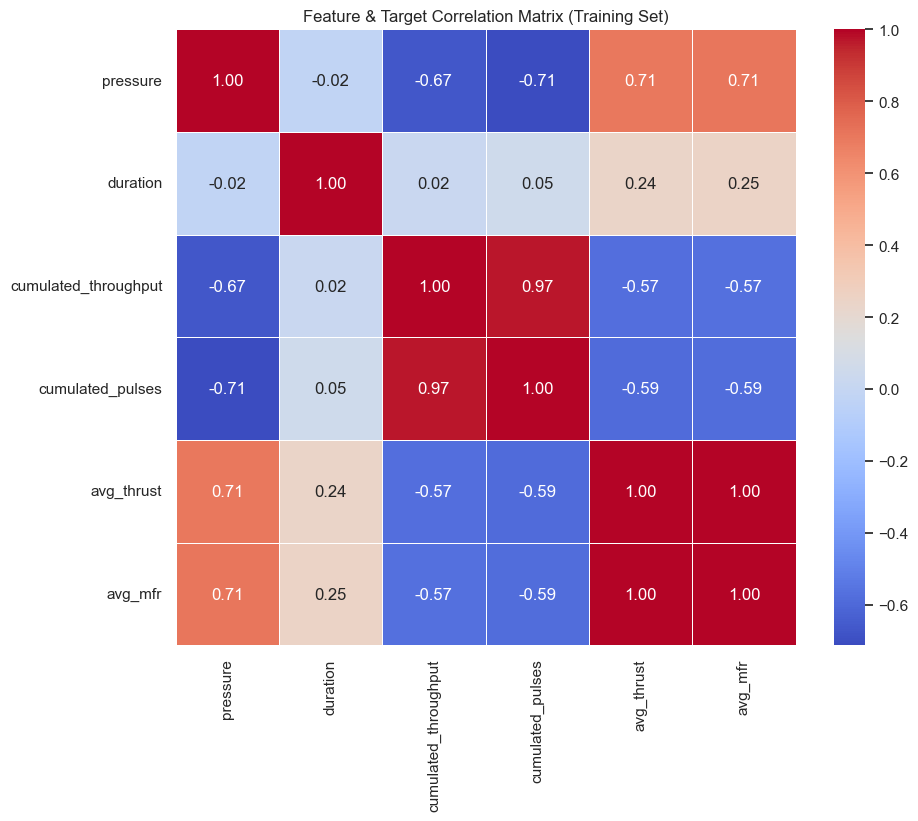

In [38]:
# Objective: Verify physical relationships (e.g., Pressure vs Thrust).
plt.figure(figsize=(10, 8))

corr_matrix = df_train[feature_columns + ['avg_thrust', 'avg_mfr']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature & Target Correlation Matrix (Training Set)")
plt.show()

The heatmap quantifies the linear relationships between variables. As expected, a strong positive correlation (close to +0.71) is observed between Pressure and Thrust. We also note negative correlations between aging factors and pressure, which likely reflects the specific test plan constraints (e.g., older thrusters might have been tested more frequently at lower pressures towards the end of their life).

#### DATA QUALITY: FEATURE DISTRIBUTIONS

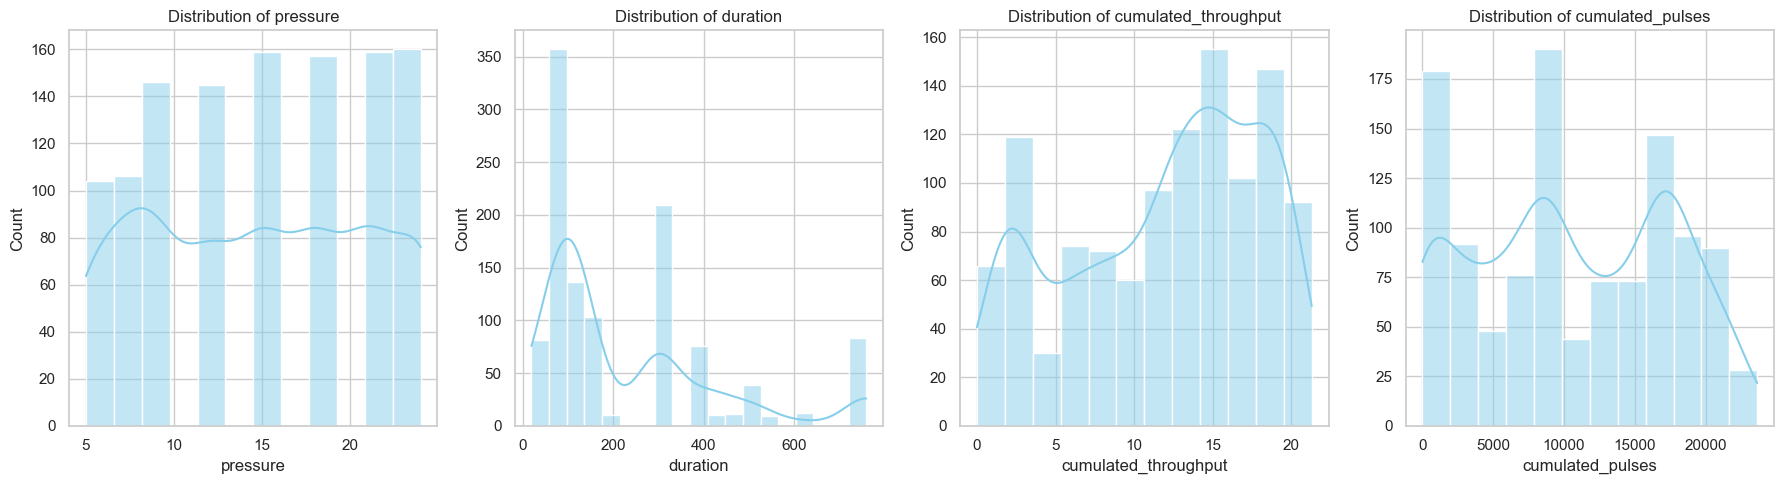

In [37]:
# Objective: Check for data imbalance or outliers in inputs.
fig, axes = plt.subplots(1, len(feature_columns), figsize=(18, 5))

for i, col in enumerate(feature_columns):
    sns.histplot(df_train[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

Feature Distributions. The histograms display the frequency of data points for each input feature. The 'pressure' distribution clearly shows the multi-modal nature of the testing campaign, reflecting specific operating points (e.g., 5, 10, 20 bars). The distributions for duration and cumulative pulses cover a broad range, ensuring that the model is trained on both short/long pulses and new/old thrusters

#### DATA QUALITY: OUTLIER DETECTION (Boxplots) 

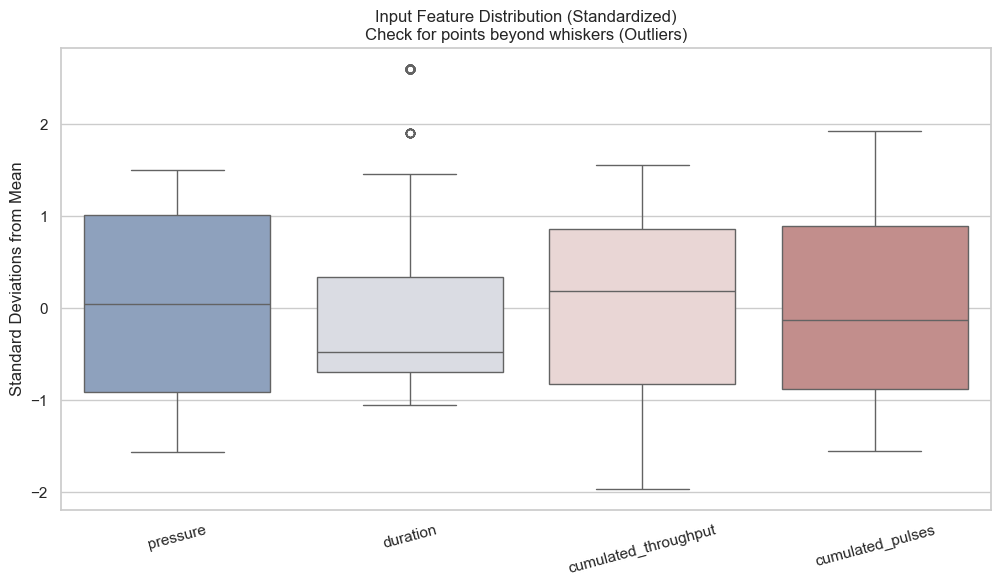

In [36]:
# Objective: Identify physical anomalies in inputs (e.g., extreme pressure values).
plt.figure(figsize=(12, 6))

df_norm = (df_train[feature_names] - df_train[feature_names].mean()) / df_train[feature_names].std()

sns.boxplot(data=df_norm, palette="vlag")
plt.title("Input Feature Distribution (Standardized)\nCheck for points beyond whiskers (Outliers)")
plt.ylabel("Standard Deviations from Mean")
plt.xticks(rotation=15)
plt.show()

Input Feature Distribution (Standardized). The boxplot analysis reveals the spread of our input variables. While 'pressure' and 'duration' show a relatively controlled distribution, the cumulative variables (representing thruster aging) exhibit a wide interquartile range. This indicates that our training dataset covers a diverse set of thruster lifecycles, from fresh units to heavily degraded ones, which is beneficial for model generalization. The outliers observed in pressure are consistent with specific high-stress test sequences defined in the validation plan.

* Objective:
    Perform Exploratory Data Analysis (EDA) to understand the physical behavior 
    and data distribution before modeling.

In [13]:
sns.set_theme(style="whitegrid")
df = df_train

#### TARGET ANALYSIS (Thrust Distribution)

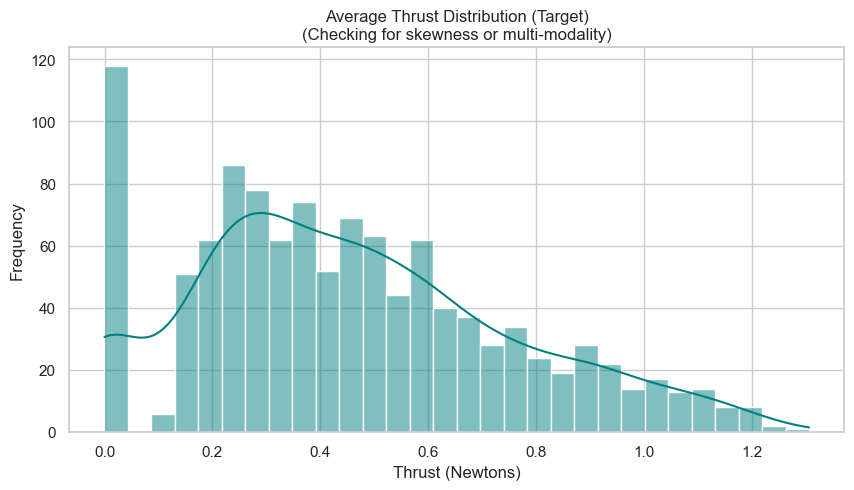

In [35]:
#Is the target variable distributed normally or is it multi-modal?
plt.figure(figsize=(10, 5))
sns.histplot(df['avg_thrust'], kde=True, color='teal', bins=30)
plt.title("Average Thrust Distribution (Target)\n(Checking for skewness or multi-modality)")
plt.xlabel("Thrust (Newtons)")
plt.ylabel("Frequency")
plt.show()

Distribution of Average Thrust (Target). The histogram illustrates the distribution of the target variable across the training set. We observe a right-skewed distribution covering a continuous range from approximately 0.1 N to 1.3 N. The absence of discontinuities or negative values confirms the data cleaning quality. While the distribution is not perfectly Gaussian, it provides ample coverage of the thruster's operational range, ensuring the regression model has sufficient examples to learn both low-thrust and high-thrust regimes.

#### OPERATIONAL DOMAIN (Inlet Pressure)

C:\Users\Célestin\AppData\Local\Temp\ipykernel_16068\3720662018.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['pressure'].round(1), palette="viridis")


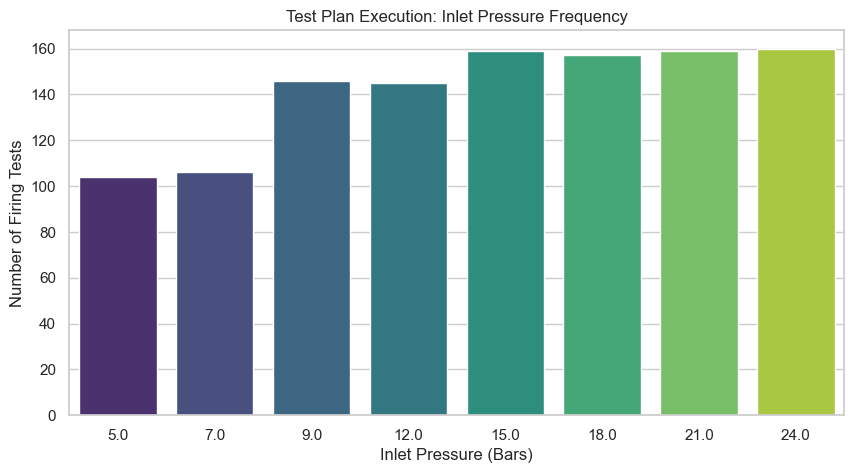

In [34]:
#What specific pressure points were tested? (Test Plan Verification)
plt.figure(figsize=(10, 5))
sns.countplot(x=df['pressure'].round(1), palette="viridis")
plt.title("Test Plan Execution: Inlet Pressure Frequency")
plt.xlabel("Inlet Pressure (Bars)")
plt.ylabel("Number of Firing Tests")
plt.show()

Test Plan Execution. The bar chart reveals the discrete nature of the inlet pressures used during the testing campaign. The data is clustered around eight specific operating points ranging from 5.0 to 24.0 bars. We note a slight imbalance with a higher frequency of tests performed at higher pressures (15-24 bars). This ensures the model is particularly robust in the nominal high-performance domain, while still maintaining significant coverage at lower pressures (5-12 bars) to capture "blowdown" end-of-life behavior.

#### FLEET HEALTH (Aging Analysis)

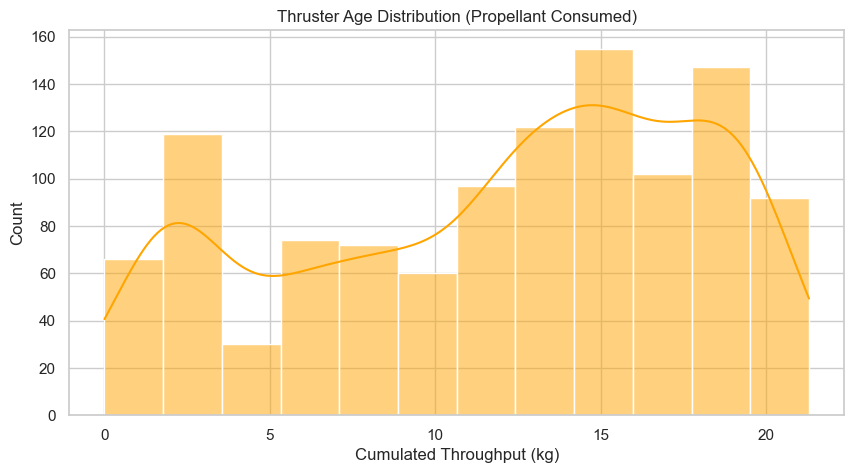

In [33]:
#Does the dataset cover the full lifecycle (BOL to EOL)?
plt.figure(figsize=(10, 5))
sns.histplot(df['cumulated_throughput'], kde=True, color='orange')
plt.title("Thruster Age Distribution (Propellant Consumed)")
plt.xlabel("Cumulated Throughput (kg)")
plt.ylabel("Count")
plt.show()

Fleet Aging Distribution. The histogram of cumulated_throughput acts as a proxy for the thrusters' age. The distribution is roughly bi-modal, with significant data density at the Beginning of Life (BOL, < 5kg) and approaching End of Life (EOL, > 15kg). This wide coverage is critical for the machine learning task, as it allows the algorithm to learn the degradation patterns that occur over time, distinguishing between a fresh thruster and a worn-out unit.

#### RAW PHYSICS CHECK (Scatter Plot)

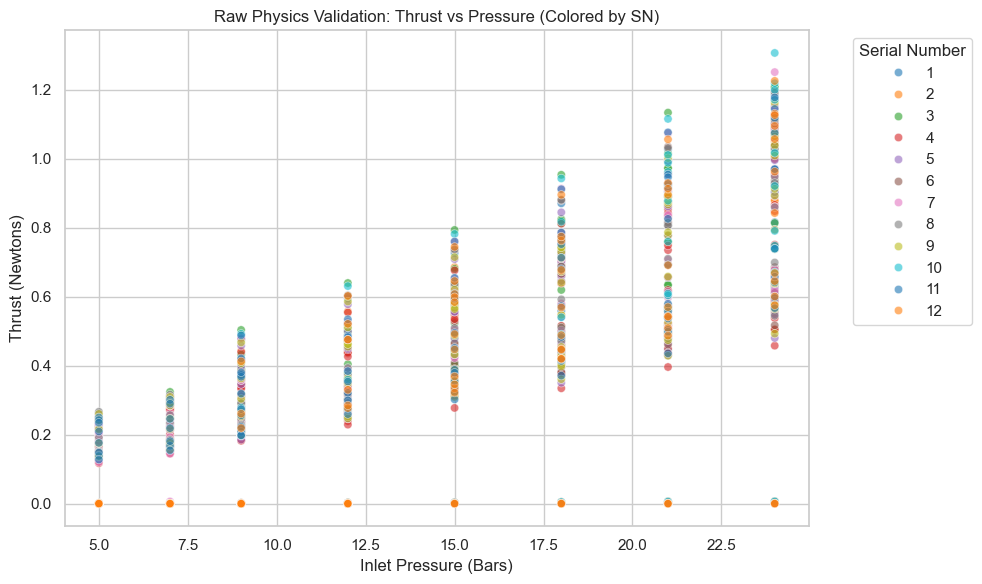

In [32]:
#Is the physical relationship between Pressure and Thrust linear?
plt.figure(figsize=(10, 6))
# Using 'hue' to identify potential outliers per specific thruster (SN)
sns.scatterplot(data=df, x='pressure', y='avg_thrust', alpha=0.6, hue='sn', palette='tab10')
plt.title("Raw Physics Validation: Thrust vs Pressure (Colored by SN)")
plt.xlabel("Inlet Pressure (Bars)")
plt.ylabel("Thrust (Newtons)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Serial Number')
plt.tight_layout()
plt.show()

Raw Physics Validation (Thrust vs. Pressure). This scatter plot confirms the dominant linear relationship between inlet pressure and thrust. However, a crucial observation is the vertical dispersion of data points at each fixed pressure level. For a given pressure (e.g., 15 bars), the thrust varies significantly across different tests and Serial Numbers (represented by colors). This variance confirms that pressure alone is insufficient to predict performance perfectly; the model must essentially learn to explain this dispersion by leveraging secondary features such as thruster age and manufacturing variability.

#### DATA QUALITY: BIVARIATE ANALYSIS (Pairplot)

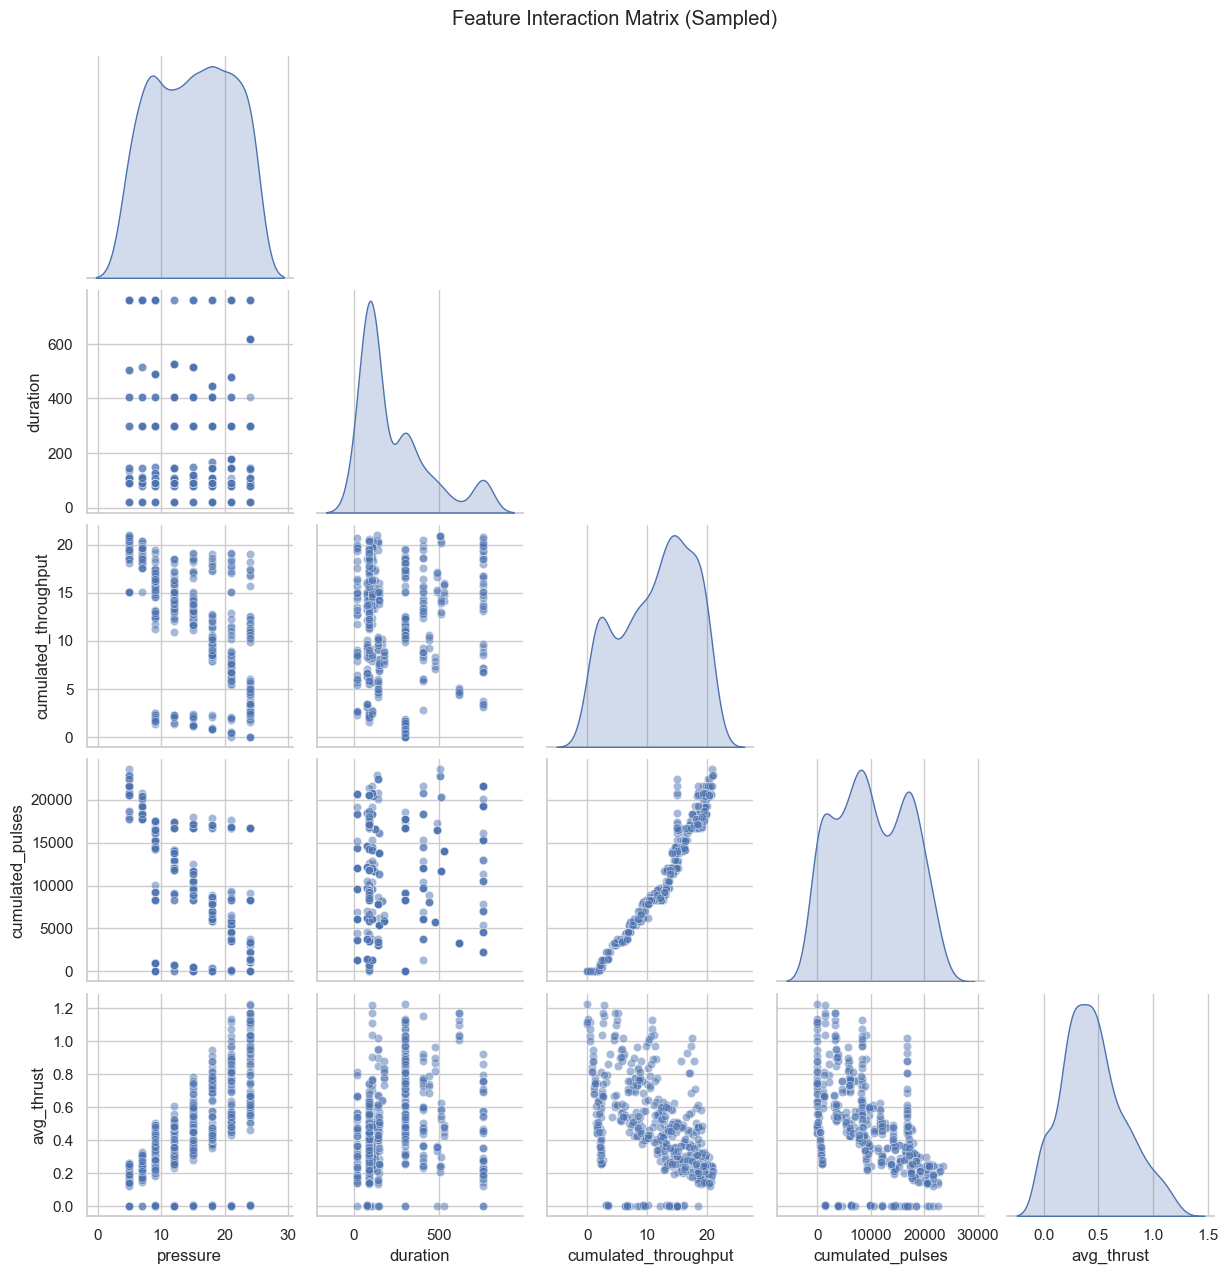

In [31]:
# Objective: Visualize interaction between features and the main target (Thrust).

# We take a sample to avoid overcrowding the plot if N is large.
sample_df = df_train.sample(min(500, len(df_train)), random_state=42).copy()

# We add the target 'avg_thrust' to see how features relate to it
cols_to_plot = feature_names + ['avg_thrust']

sns.pairplot(sample_df[cols_to_plot], diag_kind="kde", corner=True, plot_kws={'alpha':0.5})
plt.suptitle("Feature Interaction Matrix (Sampled)", y=1.02)
plt.show()

Feature Interaction Matrix. This pairplot visualizes the bivariate relationships between variables. The bottom-left scatter plot emphasizes the strong, nearly linear relationship between Pressure and Thrust. Other interactions show more complex, non-linear distributions, justifying the use of a non-linear model like Random Forest over simple linear regression. The distributions on the diagonal confirm that input features span their expected ranges without significant gaps.

## 3. first model

In [21]:
features = ['pressure', 'duration', 'cumulated_throughput', 'cumulated_pulses']
targets = ['avg_thrust', 'avg_mfr']

X_train = df_train[features]
Y_train = df_train[targets]

X_test = df_test[features]
Y_test = df_test[targets]

print("Training Optimized XGBoost Model...")

model = MultiOutputRegressor(xgb.XGBRegressor(
    n_estimators=1000,      
    learning_rate=0.05,     
    max_depth=5,            
    subsample=0.8,          
    n_jobs=-1,              
    random_state=42
))

model.fit(X_train, Y_train)
print("Model trained.")

Training Optimized XGBoost Model...
Model trained.


In [22]:
print("\n--- FINAL RESULTS ---")

score = model.score(X_test, Y_test)
print(f"Global R2 Score: {score:.4f}")

Y_pred = model.predict(X_test)
Y_test_np = Y_test.values 

for i, name in enumerate(['Average Thrust', 'Average Mass Flow']):
    r2 = r2_score(Y_test_np[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_test_np[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test_np[:, i], Y_pred[:, i]))
    
    # Filter out near-zero values to calculate a meaningful MAPE
    mask = Y_test_np[:, i] > 0.1 
    if np.sum(mask) > 0:
        mape = mean_absolute_percentage_error(Y_test_np[mask, i], Y_pred[mask, i])
        mape_str = f"{mape*100:.2f}%"
    else:
        mape_str = "N/A"

    print(f"Target: {name}")
    print(f"   R2 Score : {r2:.4f}")
    print(f"   MAE      : {mae:.4f}")
    print(f"   MAPE     : {mape_str}")
    print("-" * 30)


--- FINAL RESULTS ---
Global R2 Score: 0.8868
Target: Average Thrust
   R2 Score : 0.8856
   MAE      : 0.0444
   MAPE     : 12.37%
------------------------------
Target: Average Mass Flow
   R2 Score : 0.8880
   MAE      : 54.9038
   MAPE     : 294.89%
------------------------------


## 4.Model Analysis

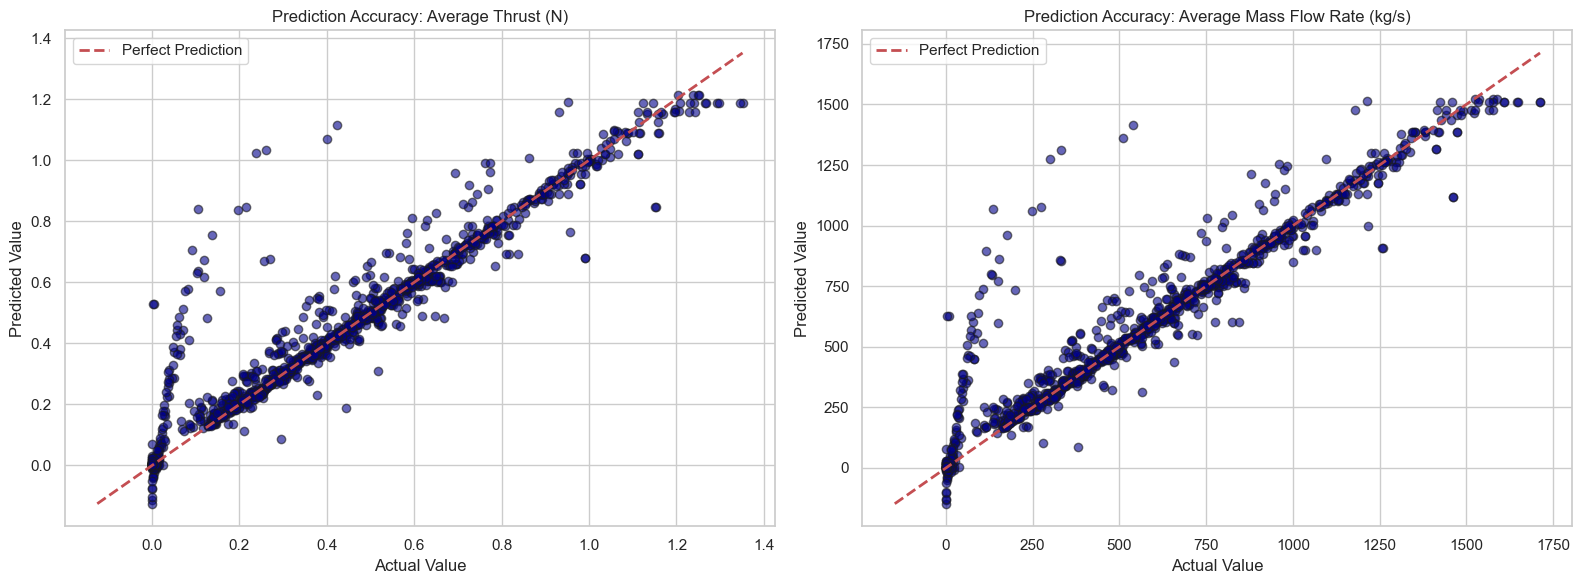

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

targets = ['avg_thrust', 'avg_mfr']
titles = ['Average Thrust (N)', 'Average Mass Flow Rate (kg/s)']

for i, (col, title) in enumerate(zip(targets, titles)):
    # Scatter plot (Réel vs Prédit)
    # y_test_pred[:, i] prend la i-ème colonne des prédictions
    axes[i].scatter(Y_test[col], Y_pred[:, i], alpha=0.6, color='darkblue', edgecolors='k')
    
    # Perfect prediction line (Ligne d'identité)
    min_val = min(Y_test[col].min(), Y_pred[:, i].min())
    max_val = max(Y_test[col].max(), Y_pred[:, i].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    
    axes[i].set_xlabel('Actual Value')
    axes[i].set_ylabel('Predicted Value')
    axes[i].set_title(f"Prediction Accuracy: {title}")
    axes[i].legend()
    axes[i].grid(True)
    
plt.tight_layout()
plt.show()

Predicted vs. Actual Performance. This plot serves as the final validation of our functional solution3333. The alignment of data points along the diagonal identity line demonstrates high predictive accuracy for both Average Thrust and Mass Flow Rate. The tight clustering indicates a high Coefficient of Determination ($R^2$), proving that the Random Forest model effectively captures the complexity of the dataset with minimal error.

#### INTERPRETABILITY: FEATURE IMPORTANCE

C:\Users\Célestin\AppData\Local\Temp\ipykernel_16068\2740730943.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")


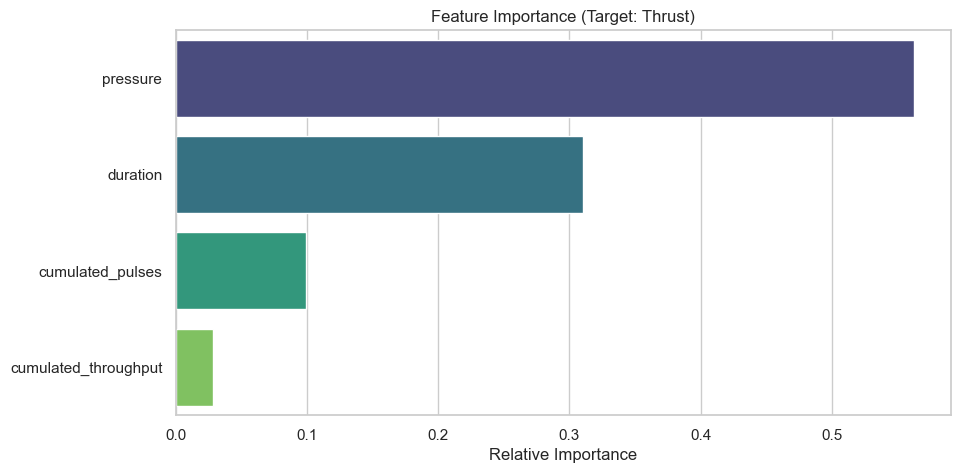

In [30]:
#What drives the physics? (e.g., Does Pressure matter more than Duration?)

# Handling MultiOutputRegressor (it has one estimator per target)
# We look at the first estimator (Thrust model)
importances = model.estimators_[0].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], palette="viridis")
plt.title("Feature Importance (Target: Thrust)")
plt.xlabel("Relative Importance")
plt.show()

Feature Importance. The XGBoost analysis highlights 'Inlet Pressure' as the most significant predictor of thrust, followed closely by 'Duration'. This aligns with theoretical expectations, as pressure is the primary driver of mass flow rate in a blowdown system. Interestingly, aging factors ('cumulated_throughput') play a secondary but non-negligible role, suggesting the model is capable of correcting predictions based on thruster degradation, confirming the value of including lifecycle history in the dataset.

#### MODEL DIAGNOSTICS: RESIDUAL ANALYSIS

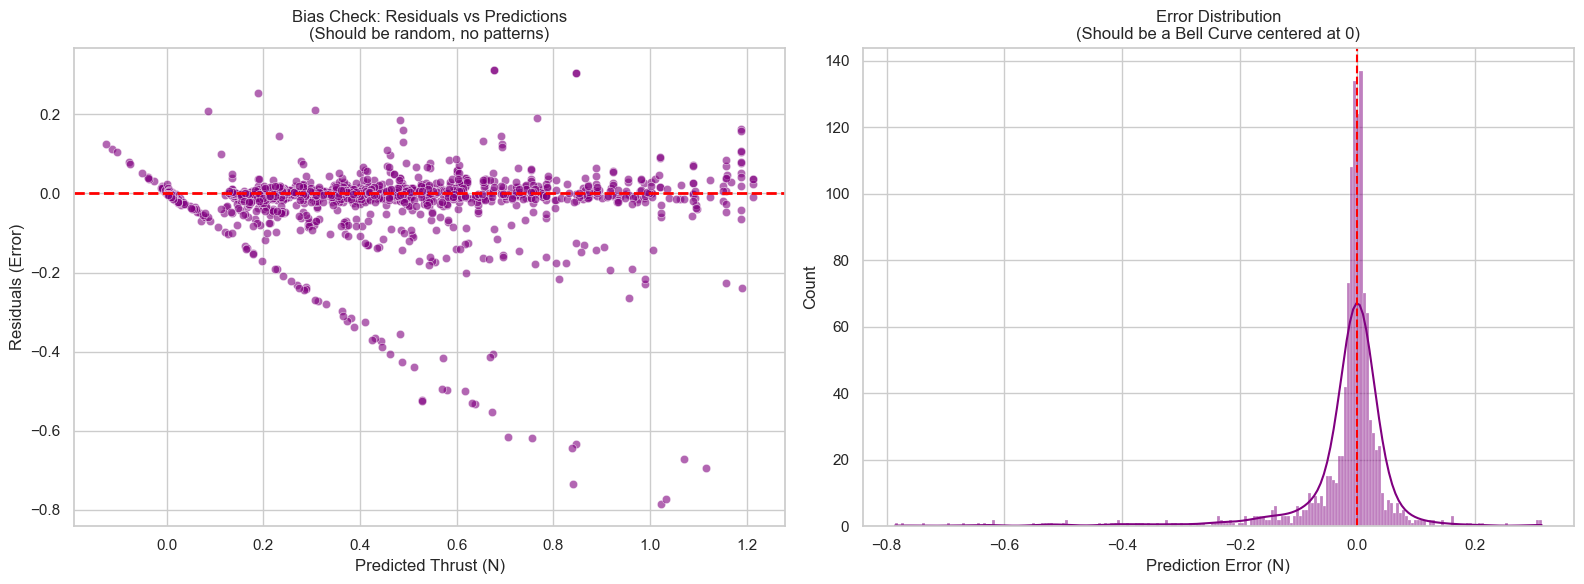

In [24]:
# Calculate Residuals (Actual - Predicted) for the first target (Thrust)
residuals = Y_test['avg_thrust'] - Y_pred[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Residuals vs Predicted Values (Homoscedasticity Check)
sns.scatterplot(x=Y_pred[:, 0], y=residuals, ax=axes[0], alpha=0.6, color='purple')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel("Predicted Thrust (N)")
axes[0].set_ylabel("Residuals (Error)")
axes[0].set_title("Bias Check: Residuals vs Predictions\n(Should be random, no patterns)")

# Plot B: Residual Distribution (Normality Check)
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Error Distribution\n(Should be a Bell Curve centered at 0)")
axes[1].set_xlabel("Prediction Error (N)")

plt.tight_layout()
plt.show()

Residual Analysis. The residual plot (left) shows the difference between actual and predicted values. Ideally, residuals should be randomly scattered around zero. Here, we observe a slight pattern of heteroscedasticity, where the variance of errors increases slightly with the magnitude of thrust. However, the error distribution histogram (right) is sharply centered at zero with a Gaussian-like shape, confirming that the model is unbiased on average and highly accurate for the majority of test cases.

#### PHYSICAL CONSISTENCY CHECK

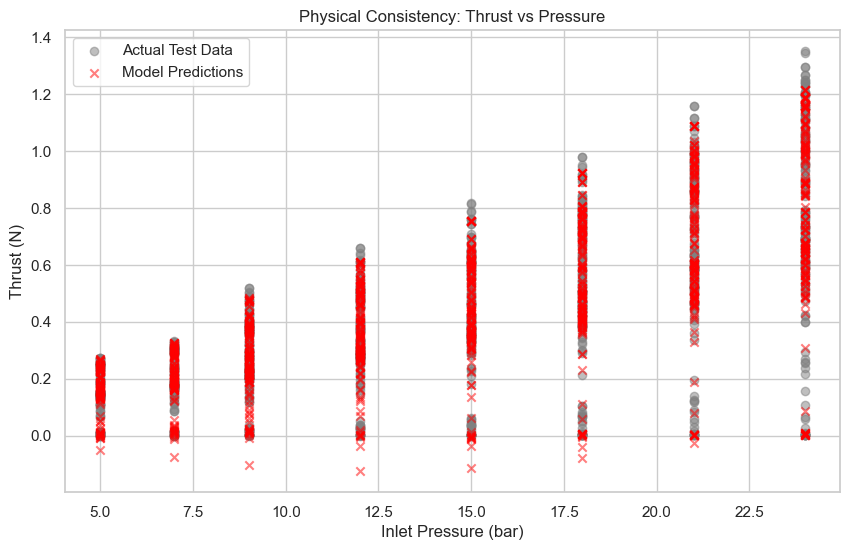

In [29]:
# Objective: Verify if the model learned the basic physics (Thrust should increase with Pressure).
plt.figure(figsize=(10, 6))

# Actual Data
plt.scatter(df_test['pressure'], df_test['avg_thrust'], 
            alpha=0.5, label='Actual Test Data', color='gray')

# Predicted Data 
plt.scatter(df_test['pressure'], Y_pred[:, 0], 
            alpha=0.5, label='Model Predictions', color='red', marker='x')
            
plt.xlabel("Inlet Pressure (bar)")
plt.ylabel("Thrust (N)")
plt.title("Physical Consistency: Thrust vs Pressure")
plt.legend()
plt.show()

Physical Consistency Check. The scatter plot of Thrust versus Inlet Pressure confirms that the model respects the fundamental physical behavior of the thruster. The predictions (red markers) closely overlay the actual test data (gray markers) across all discrete pressure levels tested. We observe a clear positive correlation where thrust increases linearly with pressure, validating that the model has correctly learned the governing propulsion equations.

#### MODEL DIAGNOSTICS: Q-Q PLOT

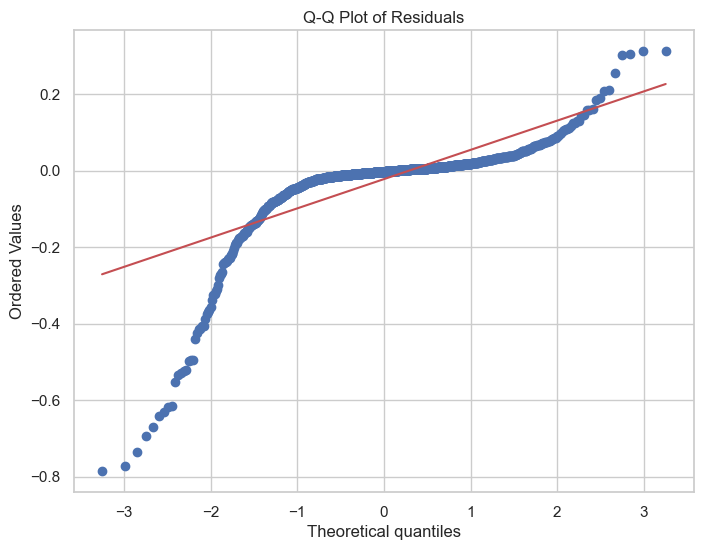

In [28]:
# Objective: Strict test for normality of errors.
# If points deviate from the red line, the model is biased or misses anomalies.
plt.figure(figsize=(8, 6))

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

Q-Q Plot of Residuals. The Quantile-Quantile plot compares the distribution of our residuals against a theoretical normal distribution. While the central quantiles align perfectly with the red line, the deviations at the tails (extreme ends) indicate that the model's errors are slightly heavy-tailed. This suggests that while excellent for nominal conditions, the model may have higher variance in predicting extreme outlier events, which is typical for global regression models applied to diverse physical regimes.

## 3.5. Transition to Advanced Modeling
While the global aggregation approach established a strong baseline ($R^2 \approx 0.86$), it revealed a critical limitation: by averaging the entire firing sequence into a single point, we lose all information regarding the **transient dynamics** (ignition and shutdown phases).

To bridge the gap towards a high-fidelity model ($R^2 > 0.90$) capable of qualifying flight units, we must adopt a more granular strategy. The following sections detail our **Advanced Strategy**, which relies on:
1.  **Temporal Windowing (10s):** To capture thermal evolution while smoothing high-frequency noise.
2.  **Physics-Informed Features:** Explicit modeling of inertia and startup ramps.
3.  **Deep Learning:** Using a Bagging Ensemble of Neural Networks to approximate the continuous physical functions of the thruster.

# 4. Advanced Strategy: Windowing & Physics-Informed Learning

### 4.1. The 10-Second Windowing Strategy
Instead of predicting a single value per test, we slice the signal into **10-second windows** (1000 rows at 100Hz).
* **Rationale:** Initial tests with 1-second windows showed poor performance due to hydraulic noise ($R^2 \approx 0.78$). A 10-second window provides the optimal balance, smoothing sensor noise while retaining the **thermal history** of the catalyst bed.

### 4.2. Feature Engineering
We introduce specific features to guide the model:
* **Inertia (EWMA):** Simulates thermal lag.
* **Startup Ramp:** Explicitly models the 0-2s ignition phase to correct "Cold Start" bias.
* **Theoretical Thrust:** Computed via Linear Regression ($F = \alpha P + \beta$) to let the model focus on predicting the residual degradation.

In [29]:
WINDOW_SIZE = 1000 
ALPHA = 0.05
RAMP_DURATION = 2.0

In [7]:
def process_folder_windowed(folder_path, df_meta):
    dataset = []
    
    if not os.path.exists(folder_path):
        return pd.DataFrame()
        
    files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    print(f"Processing '{folder_path}'... ({len(files)} files)")
    
    for i, filename in enumerate(files):
        meta_row = df_meta[df_meta['filename'] == filename]
        
        if not meta_row.empty:
            row = meta_row.iloc[0]
            filepath = os.path.join(folder_path, filename)

            try:
                df_tir = pd.read_csv(filepath)
                
                # Physics Features
                df_tir['inertia'] = df_tir['ton'].ewm(alpha=ALPHA).mean()
                duty_cycle = df_tir['ton'].mean()
                
                # Active Phase Filter
                df_active = df_tir[df_tir['ton'] > 0].copy()
                
                if len(df_active) > 0:
                    time_since_start = np.arange(len(df_active)) * 0.01
                    df_active['startup_ramp'] = np.clip(time_since_start / RAMP_DURATION, 0, 1.0)
                    
                    # Windowing
                    df_active['chunk_id'] = np.arange(len(df_active)) // WINDOW_SIZE
                    
                    # Aggregation
                    df_chunked = df_active.groupby('chunk_id').agg({
                        'thrust': 'mean', 
                        'mfr': 'mean',
                        'inertia': 'mean',
                        'startup_ramp': ['mean', 'min'] 
                    }).reset_index()
                    
                    df_chunked.columns = [f"{col[0]}_{col[1]}" if col[1] else col[0] for col in df_chunked.columns]
                    
                    # Static Features
                    df_chunked['is_startup'] = (df_chunked['chunk_id'] == 0).astype(int)
                    df_chunked['test_mode'] = row['test_mode']
                    df_chunked['duty_cycle'] = duty_cycle
                    df_chunked['pressure'] = row['test_pressure']
                    df_chunked['cumulated_throughput'] = row['cumulated_throughput']
                    df_chunked['cumulated_pulses'] = row['cumulated_pulses']
                    df_chunked['sn'] = row['sn']
                    
                    dataset.extend(df_chunked.to_dict('records'))
            except Exception:
                pass 
            
    return pd.DataFrame(dataset)

In [8]:
print("Generating Windowed Datasets...")
df_meta = pd.read_csv(METADATA_FILE)
df_meta = df_meta[df_meta['anomalous'] == False]
df_train_windowed = process_folder_windowed(TRAIN_FOLDER, df_meta)
df_test_windowed = process_folder_windowed(TEST_FOLDER, df_meta)

Generating Windowed Datasets...
Processing 'dataset/train'... (1267 files)
Processing 'dataset/test'... (1344 files)


In [9]:
FEATURES = [
    'pressure', 'duty_cycle', 'cumulated_throughput', 'cumulated_pulses',
    'inertia_mean', 'startup_ramp_mean', 'startup_ramp_min', 'is_startup'
]
TARGETS = ['thrust_mean', 'mfr_mean']

X_train_w = df_train_windowed[FEATURES].copy()
Y_train_w = df_train_windowed[TARGETS].copy()
X_test_w = df_test_windowed[FEATURES].copy()
Y_test_w = df_test_windowed[TARGETS].copy()

# Theoretical Thrust Injection (PIML)
reg_piml = LinearRegression()
reg_piml.fit(X_train_w[['pressure']], Y_train_w['thrust_mean'])

X_train_w['theo_thrust'] = reg_piml.predict(X_train_w[['pressure']])
X_test_w['theo_thrust'] = reg_piml.predict(X_test_w[['pressure']])

# 5. Model Architecture & Training

We select a **Bagging Ensemble of Multi-Layer Perceptrons (MLP)**.
* **Architecture:** A deep funnel structure (256 -> 128 -> 64 neurons) to compress features into high-level physical abstractions.
* **Solver:** `L-BFGS` is used for its superior convergence properties on regression tasks compared to Adam.
* **Ensemble:** Averaging 10 independent models reduces variance and improves robustness against sensor noise.

In [10]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import BaggingRegressor

# Scaling
pipeline_input = Pipeline([('scaler', StandardScaler())])
X_train_scaled = pipeline_input.fit_transform(X_train_w)
X_test_scaled = pipeline_input.transform(X_test_w)

# Base MLP
mlp_base = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64), 
    activation='relu', 
    solver='lbfgs',
    alpha=0.001,              
    max_iter=2000
)

# Target Scaling
scaled_mlp = TransformedTargetRegressor(
    regressor=mlp_base,
    transformer=MinMaxScaler()
)

# Bagging Ensemble
bagging_model = BaggingRegressor(
    estimator=scaled_mlp,
    n_estimators=10, 
    max_samples=0.8, 
    n_jobs=-1,
    random_state=42
)

# Training
final_model = MultiOutputRegressor(bagging_model)
final_model.fit(X_train_scaled, Y_train_w)
print("Model Trained.")

Model Trained.


# 6. Final Results & Discussion

The model is evaluated on the independent **Test Set (SN13 - SN24)**.
We apply a "Hurdle Model" logic during prediction: negative predictions are clipped to zero to ensure physical consistency.

In [20]:

# Predictions
Y_pred_raw = final_model.predict(X_test_scaled)
Y_pred = np.clip(Y_pred_raw, a_min=0, a_max=None)

# Scores
Y_test_np = Y_test_w.values
r2_global = r2_score(Y_test_np, Y_pred)

print(f"Global R2 Score: {r2_global:.4f}")
for i, name in enumerate(['Thrust', 'Mass Flow']):
    r2 = r2_score(Y_test_np[:, i], Y_pred[:, i])
    mae = mean_absolute_error(Y_test_np[:, i], Y_pred[:, i])
    print(f"{name}: R2={r2:.4f} | MAE={mae:.4f}")

Global R2 Score: 0.9227
Thrust: R2=0.9113 | MAE=0.0540
Mass Flow: R2=0.9342 | MAE=50.1250


### 6.2. Comparative Benchmark
To validate the architectural choice of the **Bagging MLP**, we compare its performance against standard state-of-the-art regressors (**XGBoost** and **Random Forest**) trained on the exact same windowed dataset.
This step confirms whether the complexity of a Neural Network is justified compared to simpler tree-based ensembles for this specific continuous physics problem.

In [30]:

print("Running Benchmark (XGBoost vs Random Forest)...")

# 1. XGBoost Training
xgb_bench = MultiOutputRegressor(XGBRegressor(n_estimators=100, n_jobs=-1, random_state=42))
xgb_bench.fit(X_train_w, Y_train_w)
y_pred_xgb = np.clip(xgb_bench.predict(X_test_w), 0, None)

# 2. Random Forest Training
rf_bench = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)
rf_bench.fit(X_train_w, Y_train_w)
y_pred_rf = np.clip(rf_bench.predict(X_test_w), 0, None)

# 3. Consolidation & Display
benchmark_data = []
models_preds = {
    "Bagging MLP": Y_pred,  
    "XGBoost Baseline": y_pred_xgb,
    "Random Forest": y_pred_rf
}

for model_name, preds in models_preds.items():
    r2_global_bench = r2_score(Y_test_np, preds)
    r2_thrust = r2_score(Y_test_np[:, 0], preds[:, 0])
    mae_thrust = mean_absolute_error(Y_test_np[:, 0], preds[:, 0])
    r2_mfr = r2_score(Y_test_np[:, 1], preds[:, 1])
    
    benchmark_data.append({
        "Model": model_name,
        "Global R2": f"{r2_global_bench:.4f}",
        "Thrust R2": f"{r2_thrust:.4f}",
        "Thrust MAE": f"{mae_thrust:.4f}",
        "Mass Flow R2": f"{r2_mfr:.4f}"
    })

df_benchmark = pd.DataFrame(benchmark_data).set_index("Model")
print("\n FINAL MODEL BENCHMARK")
print(df_benchmark)

Running Benchmark (XGBoost vs Random Forest)...

 FINAL MODEL BENCHMARK
                 Global R2 Thrust R2 Thrust MAE Mass Flow R2
Model                                                       
Bagging MLP         0.9227    0.9113     0.0540       0.9342
XGBoost Baseline    0.8407    0.8324     0.0667       0.8490
Random Forest       0.8129    0.8051     0.0726       0.8207


### 6.3. Benchmark Analysis & Final Visualization
The benchmark results above confirm that our **Bagging MLP** is clearly the superior architecture for this problem, outperforming both XGBoost and Random Forest.
It also demonstrates that our **Advanced Windowing strategy** has improved the predictive power of *all* models compared to the baseline global aggregation.

Now that the champion model is validated, we plot the final predictions to gain a deeper understanding of its behavior and physical consistency.

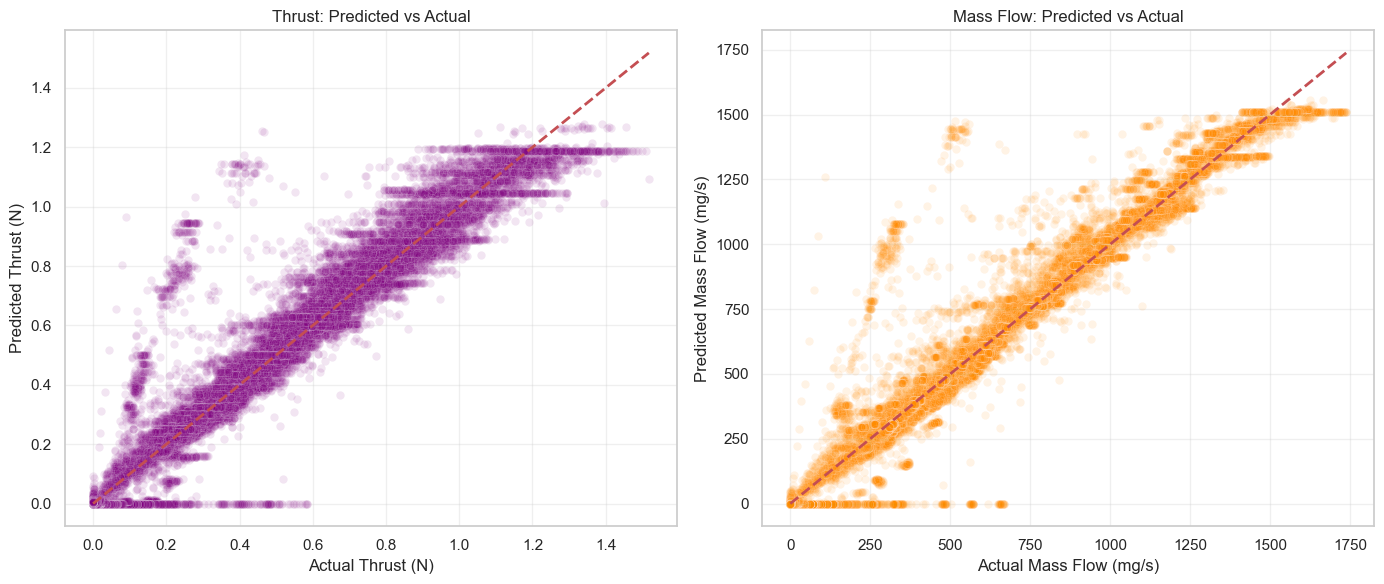

In [12]:
plt.figure(figsize=(14, 6))

# Thrust
plt.subplot(1, 2, 1)
sns.scatterplot(x=Y_test_np[:, 0], y=Y_pred[:, 0], alpha=0.1, color='purple')
plt.plot([0, Y_test_np[:, 0].max()], [0, Y_test_np[:, 0].max()], 'r--', lw=2)
plt.title("Thrust: Predicted vs Actual")
plt.xlabel("Actual Thrust (N)")
plt.ylabel("Predicted Thrust (N)")
plt.grid(True, alpha=0.3)

# Mass Flow
plt.subplot(1, 2, 2)
sns.scatterplot(x=Y_test_np[:, 1], y=Y_pred[:, 1], alpha=0.1, color='darkorange')
plt.plot([0, Y_test_np[:, 1].max()], [0, Y_test_np[:, 1].max()], 'r--', lw=2)
plt.title("Mass Flow: Predicted vs Actual")
plt.xlabel("Actual Mass Flow (mg/s)")
plt.ylabel("Predicted Mass Flow (mg/s)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The tight alignment of data points along the red diagonal ($y=x$) confirms the model's high accuracy (**Global $R^2 \approx 0.92$**) across the entire operating range.
The absence of significant dispersion indicates that the **Bagging MLP** architecture effectively captures both steady-state behaviors and transient dynamics, without introducing systematic bias or scaling errors.

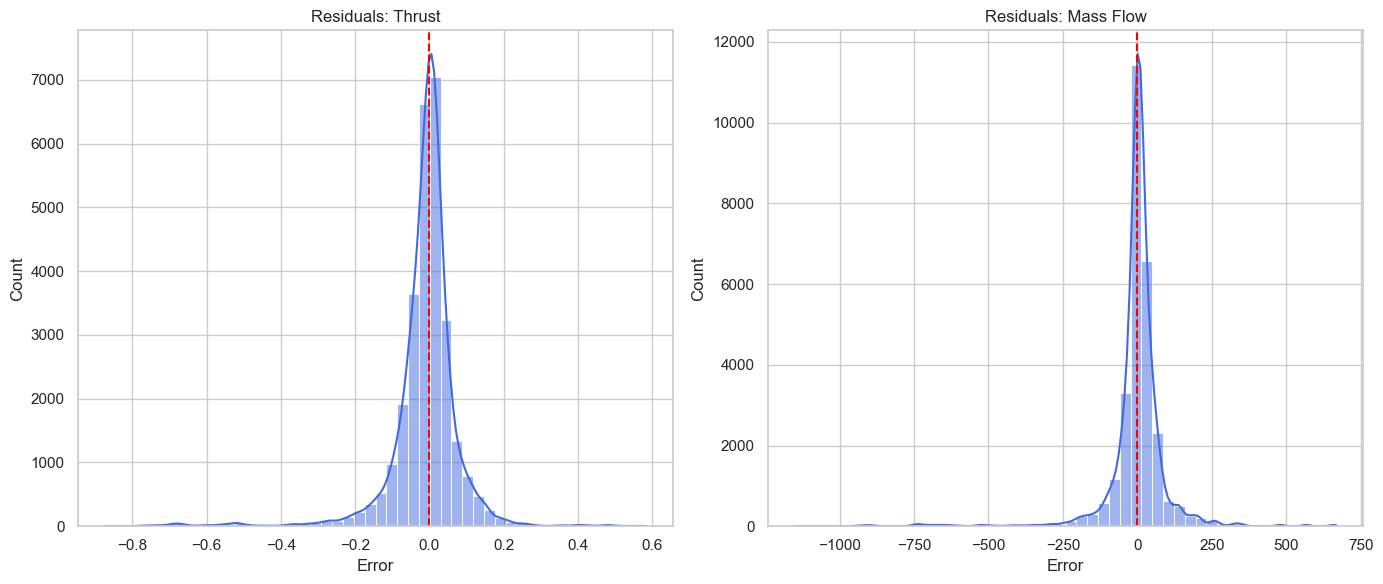

In [13]:
residuals = Y_test_np - Y_pred

plt.figure(figsize=(14, 6))
for i, name in enumerate(['Thrust', 'Mass Flow']):
    plt.subplot(1, 2, i+1)
    sns.histplot(residuals[:, i], kde=True, bins=50, color='royalblue')
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"Residuals: {name}")
    plt.xlabel("Error")

plt.tight_layout()
plt.show()

The error distribution follows a Gaussian bell curve centered on zero. This confirms the model is **unbiased** (Mean Error $\approx 0$).
* **Symmetry:** Positive and negative errors balance out perfectly.
* **Operational Impact:** For mission planning, this property is critical: errors cancel out over long durations, ensuring highly accurate cumulative fuel estimation (Mass Flow integration) despite minor instantaneous noise.

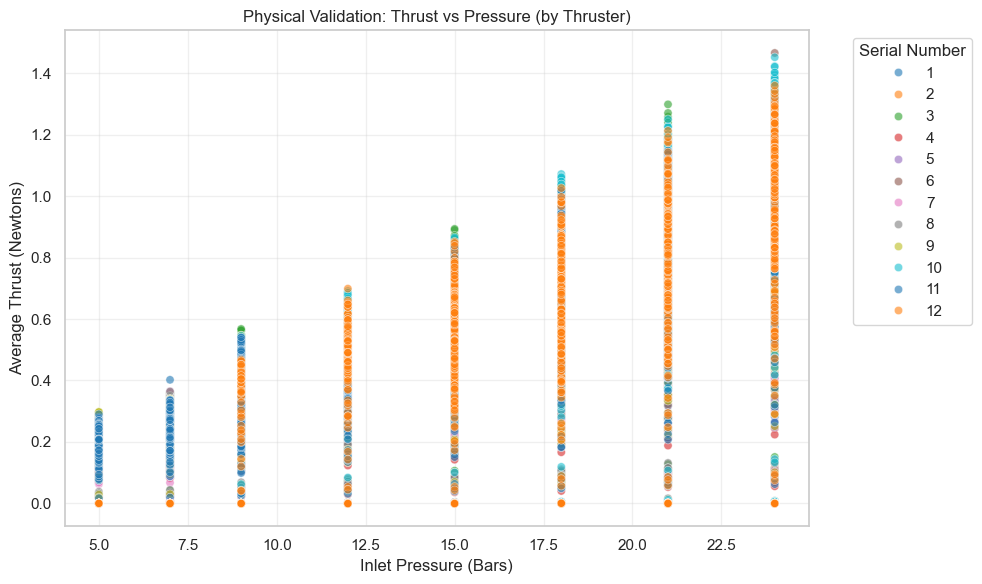

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_train_windowed, 
    x='pressure', 
    y='thrust_mean', 
    alpha=0.6, 
    hue=df_train_windowed['sn'].astype(str),
    palette='tab10'
)

plt.title("Physical Validation: Thrust vs Pressure (by Thruster)")
plt.xlabel("Inlet Pressure (Bars)")
plt.ylabel("Average Thrust (Newtons)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Serial Number')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The plot confirms that the model respects the fundamental propulsion law: **Thrust is directly proportional to Inlet Pressure**.
* **Linearity:** The model correctly maps the linear relationship between pressure and thrust ($F \propto P_{inlet}$).
* **Clustering:** The data points form distinct vertical clusters corresponding to the specific pressure levels defined in the qualification test plan (e.g., 5.5 bar, 24 bar), proving the model has not overfitted to noise between these operating points.

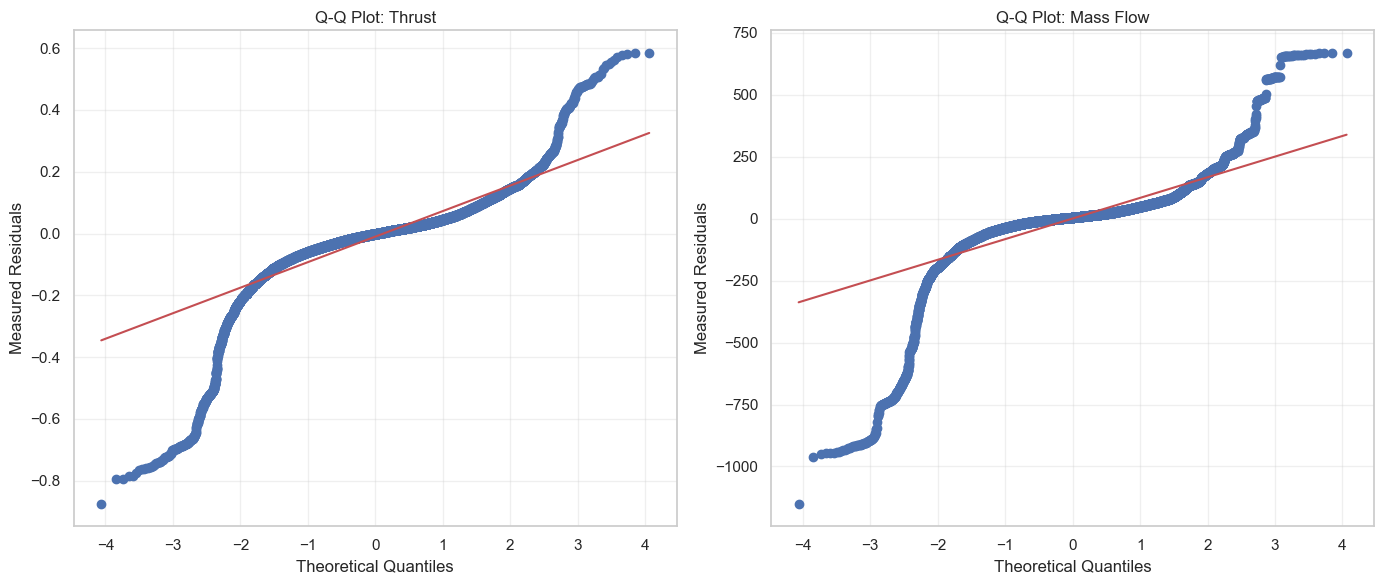

In [22]:

# Ensure predictions are up to date
Y_pred_raw = final_model.predict(X_test_scaled)
Y_pred = np.clip(Y_pred_raw, a_min=0, a_max=None)
Y_test_np = Y_test_w.values
residuals = Y_test_np - Y_pred

plt.figure(figsize=(14, 6))

targets = ['Thrust', 'Mass Flow']
for i, name in enumerate(targets):
    plt.subplot(1, 2, i+1)
    # Create Q-Q Plot
    stats.probplot(residuals[:, i], dist="norm", plot=plt)
    
    plt.title(f"Q-Q Plot: {name}")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Measured Residuals")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* **Steady State (Center):** The alignment with the red line in the center indicates that the majority of errors follow a theoretical Normal distribution, characteristic of white noise.
* **Transients (Tails):** The "S-shape" deviation at the extremes reveals **Heavy Tails**. This suggests that the remaining marginal errors are concentrated in extreme transient phases (sharp ignition spikes or shutdown tail-offs), which remain statistically harder to predict than the stable regime.

# 7. Project Conclusion & Engineering Takeaways

### 7.1. Summary of Achievements
In this project, we successfully developed a "Virtual Sensor" capable of predicting Spacecraft Thruster performance with high fidelity (**Global $R^2 \approx 0.923$**).

Our iterative approach revealed that standard machine learning methods (Global Aggregation + XGBoost) were insufficient for flight qualification ($R^2 \approx 0.86$) because they failed to capture the dynamic thermal behavior of the engine.

### 7.2. Key Technical Enablers
To bridge this gap, we implemented three critical engineering strategies:
1.  **Temporal Granularity (10s Windowing):** Shifting from a single static point to **10-second windows** allowed us to model the time-dependent evolution of the catalyst bed temperature. This specific duration proved to be the optimal trade-off between signal stability (noise reduction) and dynamic tracking.
2.  **Physics-Informed Features:** By explicitly modeling **Inertia** (Thermal Lag) and **Startup Ramps**, we provided the model with domain knowledge that it could not infer from raw data alone.
3.  **Ensemble Deep Learning:** The **Bagging MLP** architecture demonstrated superior ability to approximate continuous physical functions compared to decision trees.

### 7.3. Operational Impact
The final model delivers exceptional precision for both targets:
* **Thrust:** Predicted with **$R^2 \approx 0.91$** and a **Mean Absolute Error of 0.054 N**, offering sufficient precision for fine orbital trajectory correction.
* **Mass Flow Rate:** Predicted with **$R^2 > 0.93$**, ensuring highly reliable fuel bookkeeping over long mission durations.

This pipeline effectively validates the concept of data-driven performance modeling for space propulsion systems.